# 📚 H5AD 文件深度解析: SRP182008 (拟南芥根部 scRNA-seq)

**目标**: 从计算机视角彻底理解这个 h5ad 文件的结构、含义、以及它与其他数据集的本质区别。

---

## 1. 什么是 h5ad 文件?

h5ad 是 AnnData 的二进制存储格式，背后是一个 HDF5 文件。它用 5 个核心组件来描述单细胞数据:

```
┌─────────────────────────────────────────────────────────────┐
│                    AnnData / h5ad 结构                        │
│                                                             │
│  adata.X        ← 表达矩阵 (cells × genes), 核心数据         │
│  adata.obs      ← 细胞元数据表 (每个细胞一行)                │
│  adata.var      ← 基因元数据表 (每个基因一行)                │
│  adata.uns      ← 非结构化字典 (全局信息)                    │
│  adata.raw      ← 原始数据备份 (处理前的完整矩阵)            │
│  adata.layers   ← 多层表达矩阵 (counts, norm_log 等)        │
│  adata.obsm     ← 多维嵌入 (PCA, UMAP, 细胞嵌入向量等)       │
│  adata.obsp     ← 稀疏邻接矩阵 (KNN 图)                     │
│  adata.varm     ← 基因多维注释                                │
└─────────────────────────────────────────────────────────────┘
```

> **类比**: 把 h5ad 想象成一个 Excel 文件, X 是第一个 sheet 的数值矩阵, obs 是第二个 sheet 的细胞注释表, var 是第三个 sheet 的基因注释表。只不过它是二进制格式, 稀疏矩阵可以压缩存储。

---

## 2. 加载数据 (带 NumPy 2.0 兼容补丁)

**注意**: 当前环境使用 NumPy 2.0, SRP182008.h5ad 使用旧版 h5ad 格式 (`np.string_` 已移除), 需要补丁。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import scanpy as sc

# NumPy 2.0 兼容性补丁
# SRP182008.h5ad 使用旧版 h5ad 格式, np.string_ 在 NumPy 2.0 中已移除
if not hasattr(np, 'string_'):
    np.string_ = np.bytes_

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=80, facecolor='white')

DATA_DIR = '../data/'
adata = sc.read_h5ad(DATA_DIR + 'SRP182008.h5ad')
print(f"✅ 数据加载成功: {adata.n_obs} cells × {adata.n_vars} genes")

/data/luolie/conda/envs/scclubench-main/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


✅ 数据加载成功: 13514 cells × 53678 genes


---

## 3. 整体结构鸟瞰

先看这个文件有什么、缺什么, 做到心里有数。

In [2]:
# 3.1 矩阵基本信息
print("=" * 60)
print("📐 矩阵形状")
print("=" * 60)
print(f"  adata.shape          = {adata.shape}")
print(f"  adata.n_obs (细胞数) = {adata.n_obs}")
print(f"  adata.n_vars (基因数)= {adata.n_vars}")
print(f"  adata.X 存储类型     = {type(adata.X).__name__}")
print(f"  adata.X 数据类型     = {adata.X.dtype}")

# 稀疏度 = 零元素占比
if sp.issparse(adata.X):
    sparsity = 1 - adata.X.nnz / (adata.n_obs * adata.n_vars)
else:
    X_dense = np.asarray(adata.X)
    sparsity = 1 - np.count_nonzero(X_dense) / X_dense.size
print(f"  稀疏度 (零占比)      = {sparsity:.4f} ({sparsity*100:.2f}%)")
print(f"  非零元素数量         = {adata.X.nnz if sp.issparse(adata.X) else np.count_nonzero(X_dense):,}")

# 内存估算
nnz = adata.X.nnz if sp.issparse(adata.X) else adata.n_obs * adata.n_vars
dense_mem_mb = (adata.n_obs * adata.n_vars * 8) / 1e6  # float64
sparse_mem_mb = (nnz * 8 + (adata.n_obs + 1) * 4 + nnz * 4) / 1e6  # float64 + indices + indptr
print(f"\n  💾 若存为 dense (float64): ~{dense_mem_mb:.0f} MB")
print(f"  💾 当前 sparse 实际占用: ~{sparse_mem_mb:.0f} MB")
print(f"  📦 压缩比: {dense_mem_mb/sparse_mem_mb:.1f}x")

📐 矩阵形状
  adata.shape          = (13514, 53678)
  adata.n_obs (细胞数) = 13514
  adata.n_vars (基因数)= 53678
  adata.X 存储类型     = csr_matrix
  adata.X 数据类型     = float64
  稀疏度 (零占比)      = 0.9760 (97.60%)
  非零元素数量         = 17,378,932

  💾 若存为 dense (float64): ~5803 MB
  💾 当前 sparse 实际占用: ~209 MB
  📦 压缩比: 27.8x


In [3]:
# 3.2 所有组件检查
print("=" * 60)
print("🗂️  AnnData 组件清单")
print("=" * 60)

components = {
    "adata.X":       (f"矩阵 {adata.shape}",          bool(adata.X.nnz if sp.issparse(adata.X) else np.count_nonzero(adata.X))),
    "adata.obs":     (f"{len(adata.obs.columns)} 列", True),
    "adata.var":     (f"{len(adata.var.columns)} 列", len(adata.var) > 0),
    "adata.raw":     (f"{adata.raw.shape if adata.raw else None}", adata.raw is not None),
    "adata.layers":  (f"{list(adata.layers.keys()) if adata.layers else []}", bool(adata.layers)),
    "adata.obsm":    (f"{list(adata.obsm.keys()) if adata.obsm else []}", bool(adata.obsm)),
    "adata.obsp":    (f"{'有' if adata.obsp else '无'}", bool(adata.obsp)),
    "adata.uns":     (f"{len(adata.uns)} 项", bool(adata.uns)),
}

for name, (info, exists) in components.items():
    status = "✅" if exists else "❌"
    print(f"  {status} {name:<16} {info}")

🗂️  AnnData 组件清单
  ✅ adata.X          矩阵 (13514, 53678)
  ✅ adata.obs        13 列
  ✅ adata.var        1 列
  ✅ adata.raw        (13514, 53678)
  ❌ adata.layers     []
  ✅ adata.obsm       ['X_tsne', 'X_umap']
  ❌ adata.obsp       无
  ❌ adata.uns        0 项


---

## 4. 表达矩阵 X 的详细解析

**计算机视角的关键问题**: X 里面到底是 counts 还是已经处理过的数据?

📊 表达矩阵 X 数值分析
采样 200,000 个非零值进行分析

  X.data 范围:    [1.0000, 1042.0000]
  X.data 均值:    2.7890
  X.data 中位数:  1.0000
  X.data 标准差:  9.8730
  X.data 分位数:  25%=1.00, 75%=2.00, 95%=8.00

  是否接近整数:  True ← ✅ 是原始 Counts


/tmp/ipykernel_1685519/2643833946.py:39: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/2643833946.py:39: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/2643833946.py:39: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/2643833946.py:39: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/2643833946.py:39: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/2643833946.py:39: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/2643833946.py:40: UserWarning: Glyph 20998 (\N{CJK UN

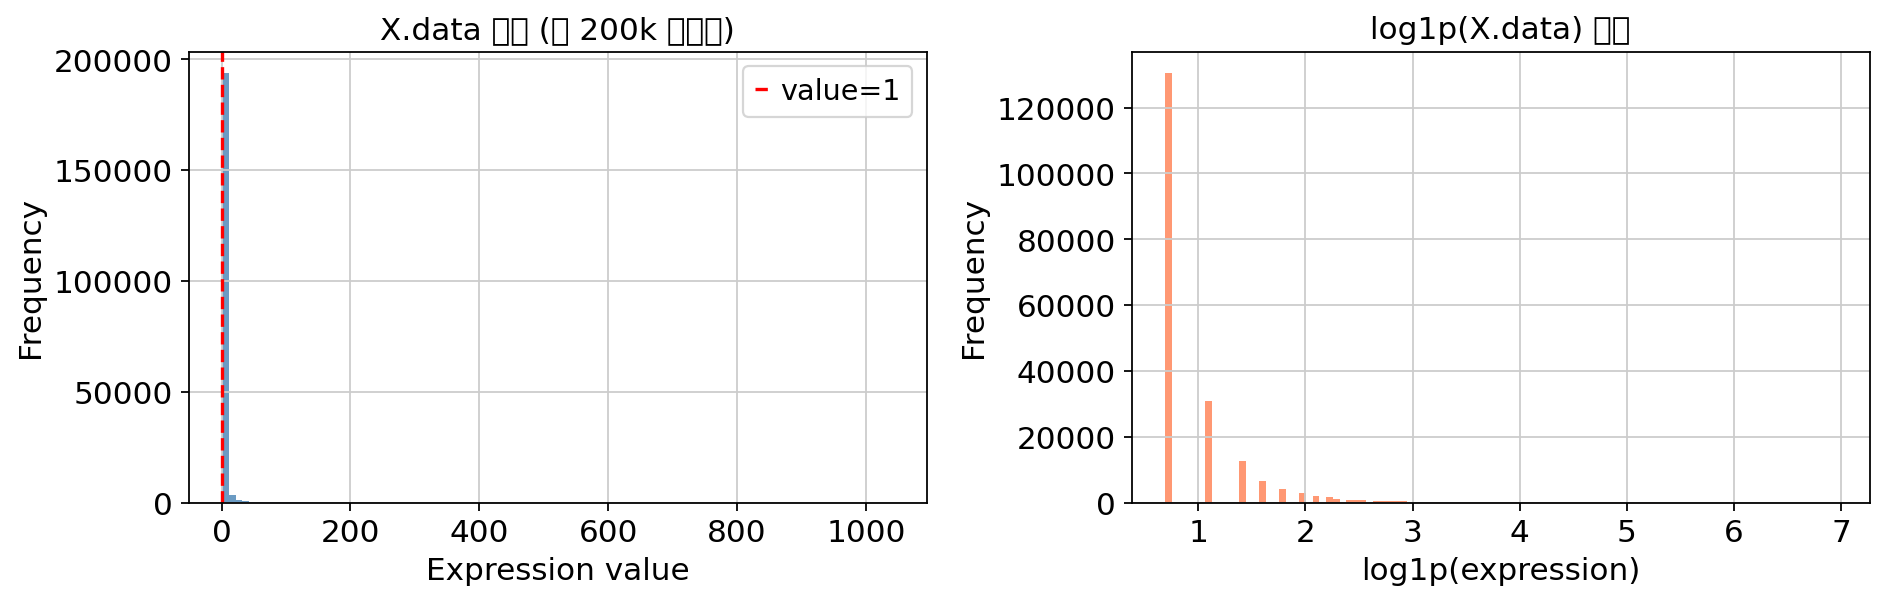


  📊 图表已保存到 notebooks_figures/h5ad_anatomy_x_distribution.png


In [4]:
# 4.1 X 的数据范围
print("=" * 60)
print("📊 表达矩阵 X 数值分析")
print("=" * 60)

if sp.issparse(adata.X):
    # 只采样非零值分析 (全量转dense太慢)
    data_sample = adata.X.data[:200_000]
    print(f"采样 {len(data_sample):,} 个非零值进行分析")
    
    print(f"\n  X.data 范围:    [{data_sample.min():.4f}, {data_sample.max():.4f}]")
    print(f"  X.data 均值:    {data_sample.mean():.4f}")
    print(f"  X.data 中位数:  {np.median(data_sample):.4f}")
    print(f"  X.data 标准差:  {data_sample.std():.4f}")
    print(f"  X.data 分位数:  25%={np.percentile(data_sample,25):.2f}, 75%={np.percentile(data_sample,75):.2f}, 95%={np.percentile(data_sample,95):.2f}")
    
    # 检验是否为整数 (原始 counts 的标志)
    is_integer = np.allclose(data_sample, data_sample.astype(int), atol=1e-3)
    print(f"\n  是否接近整数:  {is_integer} ← {'✅ 是原始 Counts' if is_integer else '⚠️ 可能已归一化'}")
    
    # 分布可视化
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 直方图 (原始 counts 在 0-100 范围)
    axes[0].hist(data_sample, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
    axes[0].set_xlabel('Expression value')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('X.data 分布 (前 200k 非零值)')
    axes[0].axvline(1, color='red', linestyle='--', label='value=1')
    axes[0].legend()
    
    # log 尺度
    log_data = np.log1p(data_sample)
    axes[1].hist(log_data, bins=100, color='coral', edgecolor='none', alpha=0.8)
    axes[1].set_xlabel('log1p(expression)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('log1p(X.data) 分布')
    
    plt.tight_layout()
    plt.savefig('../notebooks_figures/h5ad_anatomy_x_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n  📊 图表已保存到 notebooks_figures/h5ad_anatomy_x_distribution.png")

In [5]:
# 4.2 与 Seurat 注释的 nCount/nFeature 对比
print("=" * 60)
print("🔍 验证 X 与 obs 中的 QC 指标是否一致")
print("=" * 60)

# 从 obs 读取 QC 指标
nCount = adata.obs['nCount_RNA'].values
nFeature = adata.obs['nFeature_RNA'].values

# 从 X 重新计算
row_sums = np.array(adata.X.sum(axis=1)).flatten()
row_nz = np.array((adata.X > 0).sum(axis=1)).flatten()

# 对比
count_match = np.allclose(nCount, row_sums, atol=1e-3)
feat_match = np.allclose(nFeature, row_nz, atol=1)

print(f"\n  nCount_RNA 验证:")
print(f"    obs 记录值: min={nCount.min():.1f}, median={np.median(nCount):.1f}, max={nCount.max():.1f}")
print(f"    X 重新计算: min={row_sums.min():.1f}, median={np.median(row_sums):.1f}, max={row_sums.max():.1f}")
print(f"    {'✅ 完全一致' if count_match else '❌ 不一致 — obs 记录可能有问题'}")

print(f"\n  nFeature_RNA 验证:")
print(f"    obs 记录值: min={nFeature.min()}, median={np.median(nFeature):.0f}, max={nFeature.max()}")
print(f"    X 重新计算: min={row_nz.min()}, median={np.median(row_nz):.0f}, max={row_nz.max()}")
print(f"    {'✅ 完全一致' if feat_match else '⚠️ 轻微差异 (可能因浮点精度)'}")

🔍 验证 X 与 obs 中的 QC 指标是否一致

  nCount_RNA 验证:
    obs 记录值: min=500.0, median=1889.5, max=39150.0
    X 重新计算: min=500.0, median=1889.5, max=39150.0
    ✅ 完全一致

  nFeature_RNA 验证:
    obs 记录值: min=234, median=1007, max=3812
    X 重新计算: min=234, median=1007, max=3812
    ✅ 完全一致


---

## 5. obs (细胞元数据) 逐列解析

**这是理解一个 h5ad 文件最重要的部分** — obs 告诉你每个细胞来自哪里、属于什么类型。

In [6]:
print("=" * 60)
print("🧬 obs 逐列解析 (细胞元数据)")
print("=" * 60)

for col in adata.obs.columns:
    dtype = adata.obs[col].dtype
    nunique = adata.obs[col].nunique()
    null_count = adata.obs[col].isnull().sum()
    
    print(f"\n  📌 {col}")
    print(f"     dtype: {dtype}, 唯一值数: {nunique}, 空值: {null_count}")
    
    if nunique <= 20:
        dist = adata.obs[col].value_counts()
        print(f"     分布:\n{dist.to_string()}")
    else:
        vals = adata.obs[col]
        if pd.api.types.is_numeric_dtype(vals):
            print(f"     统计: min={vals.min():.2g}, median={vals.median():.2g}, max={vals.max():.2g}")
        else:
            print(f"     示例: {list(vals.unique()[:5])}")

🧬 obs 逐列解析 (细胞元数据)

  📌 Orig.ident
     dtype: object, 唯一值数: 1, 空值: 0
     分布:
Orig.ident
SRX5290443    13514

  📌 nCount_RNA
     dtype: float64, 唯一值数: 5778, 空值: 0
     统计: min=5e+02, median=1.9e+03, max=3.9e+04

  📌 nFeature_RNA
     dtype: int32, 唯一值数: 2969, 空值: 0
     统计: min=2.3e+02, median=1e+03, max=3.8e+03

  📌 Percent.mt
     dtype: float64, 唯一值数: 66, 空值: 0
     统计: min=0, median=0, max=0.15

  📌 Seurat_clusters
     dtype: object, 唯一值数: 24, 空值: 0
     示例: ['2', '14', '5', '12', '22']

  📌 Celltype
     dtype: object, 唯一值数: 15, 空值: 0
     分布:
Celltype
Root stele            2569
Root cortex           1751
Phloem/Pericycle      1524
Root hair             1153
Columella root cap    1082
Lateral root cap       948
Root endodermis        854
Unknow                 805
Companion cell         690
S phase                478
Protoxylem             396
G2/M phase             354
Sieve element          344
Metaxylem              300
Root epidermis         266

  📌 Dataset
     dtype: obj

### obs 列的生物学含义

| 列名 | 含义 | 拟南芥数据中的值 |
|------|------|----------------|
| `Orig.ident` | 数据来源标识 (Seurat 惯例) | 全部为 `"SRP182008"` — 说明只有 1 个来源 |
| `nCount_RNA` | 每个细胞的 RNA 总分子数 (原始 counts 之和) | 500 ~ 39,150, 中位数 ~1,890 |
| `nFeature_RNA` | 每个细胞表达了多少个基因 (>0 的基因数) | 234 ~ 3,812, 中位数 ~1,007 |
| `Percent.mt` | 线粒体基因表达占比 | 0 ~ 66% — **拟南芥根部线粒体基因不是 `MT-` 开头, 此列可能无效** |
| `Seurat_clusters` | Seurat 的初始聚类结果 | 24 个 cluster |
| `Celltype` | **细胞类型注释** (Ground Truth) | 15 种细胞类型, 是 benchmark 的标签 |
| `Dataset` | 数据集名称 | 全部为 `"SRP182008"` |
| `Tissue` | 组织来源 | 全部为 `"Root"` (根部) |
| `Organ` | 器官 | 全部为 `"root"` |
| `Condition` | 实验条件 | 全部相同 |
| `Genotype` | 基因型 | 全部相同 |
| `Libraries` | 建库方法 | 全部相同 |
| `ACE` | 不明注释 | — |

🎯 Celltype (Ground Truth 标签) 分布


/tmp/ipykernel_1685519/3372906845.py:15: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/3372906845.py:15: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/3372906845.py:16: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.savefig('../notebooks_figures/h5ad_anatomy_celltype_dist.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_1685519/3372906845.py:16: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.savefig('../notebooks_figures/h5ad_anatomy_celltype_dist.png', dpi=150, bbox_inches='tight')
/data/luolie/conda/envs/scclubench-main/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

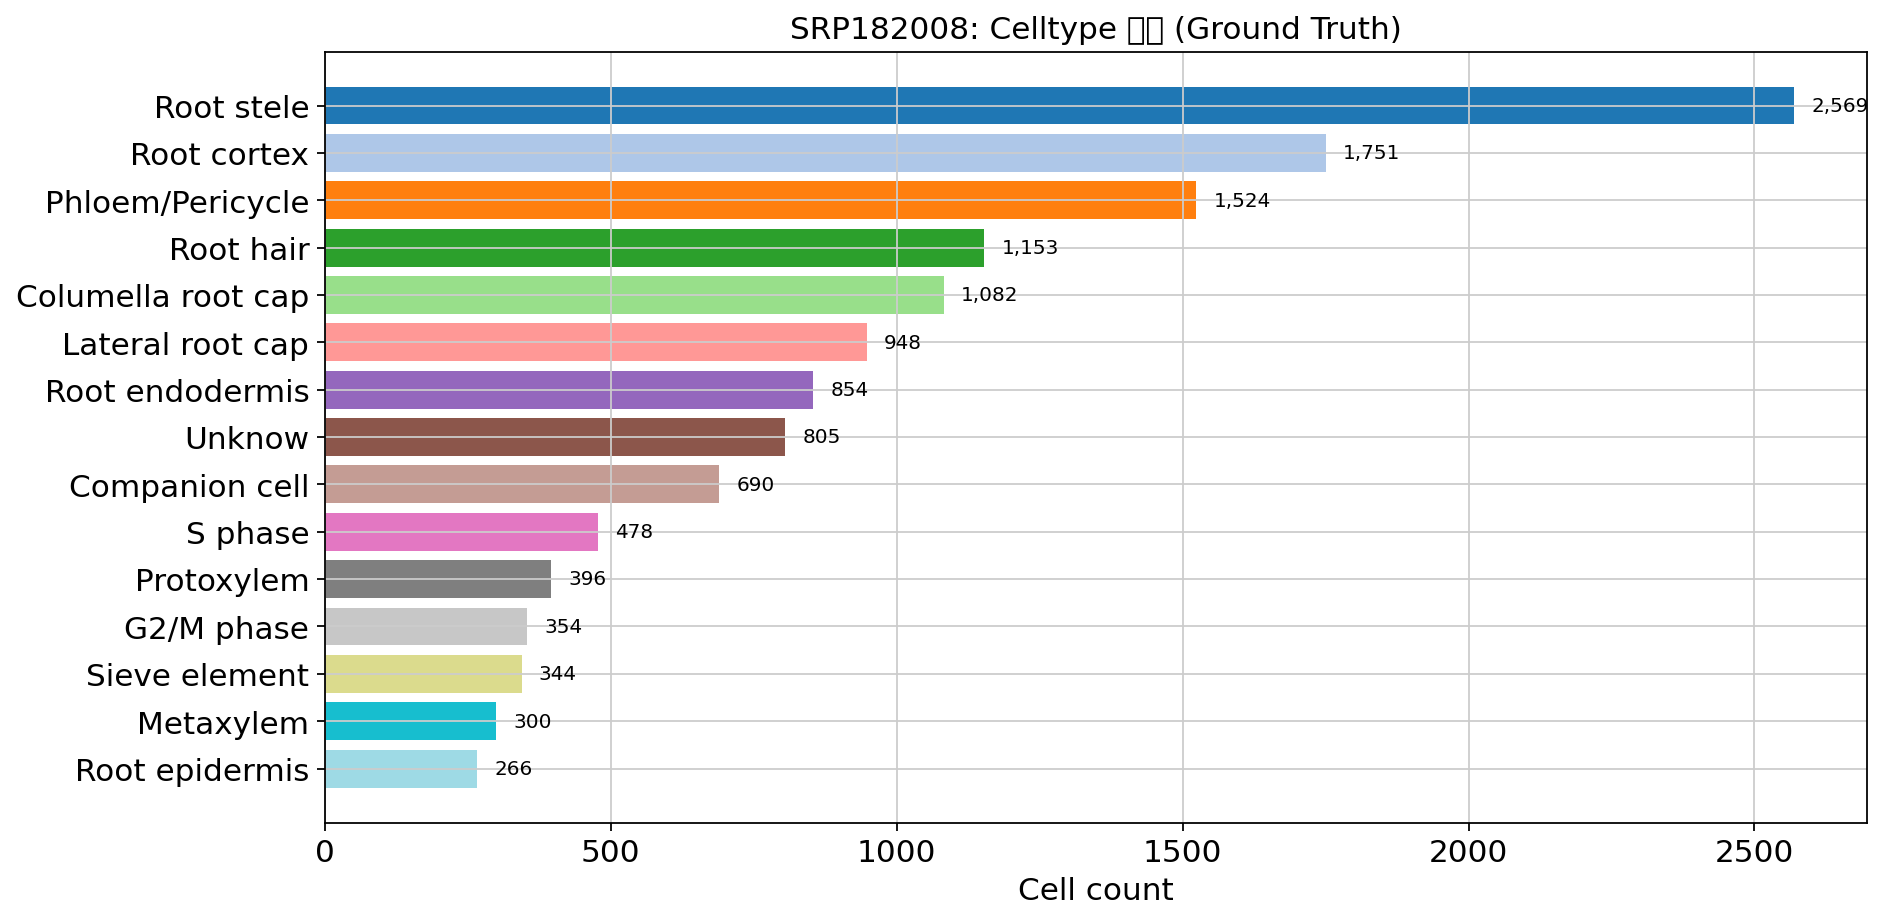


  📊 图表已保存

  共 15 种细胞类型, 最多: Root stele (2,569), 最少: Root epidermis (266)


In [7]:
# 5.1 Celltype 可视化
print("=" * 60)
print("🎯 Celltype (Ground Truth 标签) 分布")
print("=" * 60)

celltype_counts = adata.obs['Celltype'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(celltype_counts)))
bars = ax.barh(celltype_counts.index[::-1], celltype_counts.values[::-1], color=colors[::-1])
ax.set_xlabel('Cell count')
ax.set_title('SRP182008: Celltype 分布 (Ground Truth)')
for bar, val in zip(bars, celltype_counts.values[::-1]):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../notebooks_figures/h5ad_anatomy_celltype_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n  📊 图表已保存")
print(f"\n  共 {len(celltype_counts)} 种细胞类型, 最多: {celltype_counts.index[0]} ({celltype_counts.values[0]:,}), 最少: {celltype_counts.index[-1]} ({celltype_counts.values[-1]:,})")

### ⚠️ 重要发现: Celltype 中的 `"Unknow"` 类别

仔细看 Celltype 分布, 发现有 **805 个细胞被标注为 `"Unknow"`** (Unknown)。

这在 benchmark 中是合理的——部分细胞确实难以注释。但意味着:

- 如果用 Celltype 作为 ground truth 做聚类评估, 805 个 `"Unknow"` 细胞会导致基准指标计算出现偏差
- **建议**: 聚类前考虑过滤掉 `"Unknow"` 细胞, 或者在评估时只比较已注释细胞
- 不同方法对 Unknown 细胞处理策略不同 (有的保留、有的过滤)

### Seurat_clusters vs Celltype

有趣的是, Seurat 给出了 24 个 cluster, 而 Celltype 只有 15 种类型。说明:
- Seurat_clusters 是无监督聚类结果 (可能过细)
- Celltype 是注释后的细胞类型 (经过人工合并)

🔀 Seurat_clusters (24) vs Celltype (15)

交叉表形状: (15, 24) (Celltype × Seurat_clusters)


/tmp/ipykernel_1685519/1557424652.py:14: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/1557424652.py:14: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/1557424652.py:14: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/1557424652.py:14: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/1557424652.py:14: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/1557424652.py:14: UserWarning: Glyph 23637 (\N{CJK UNIFIED IDEOGRAPH-5C55}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/1557424652.py:14: UserWarning: Glyph 31034 (\N{CJK UN

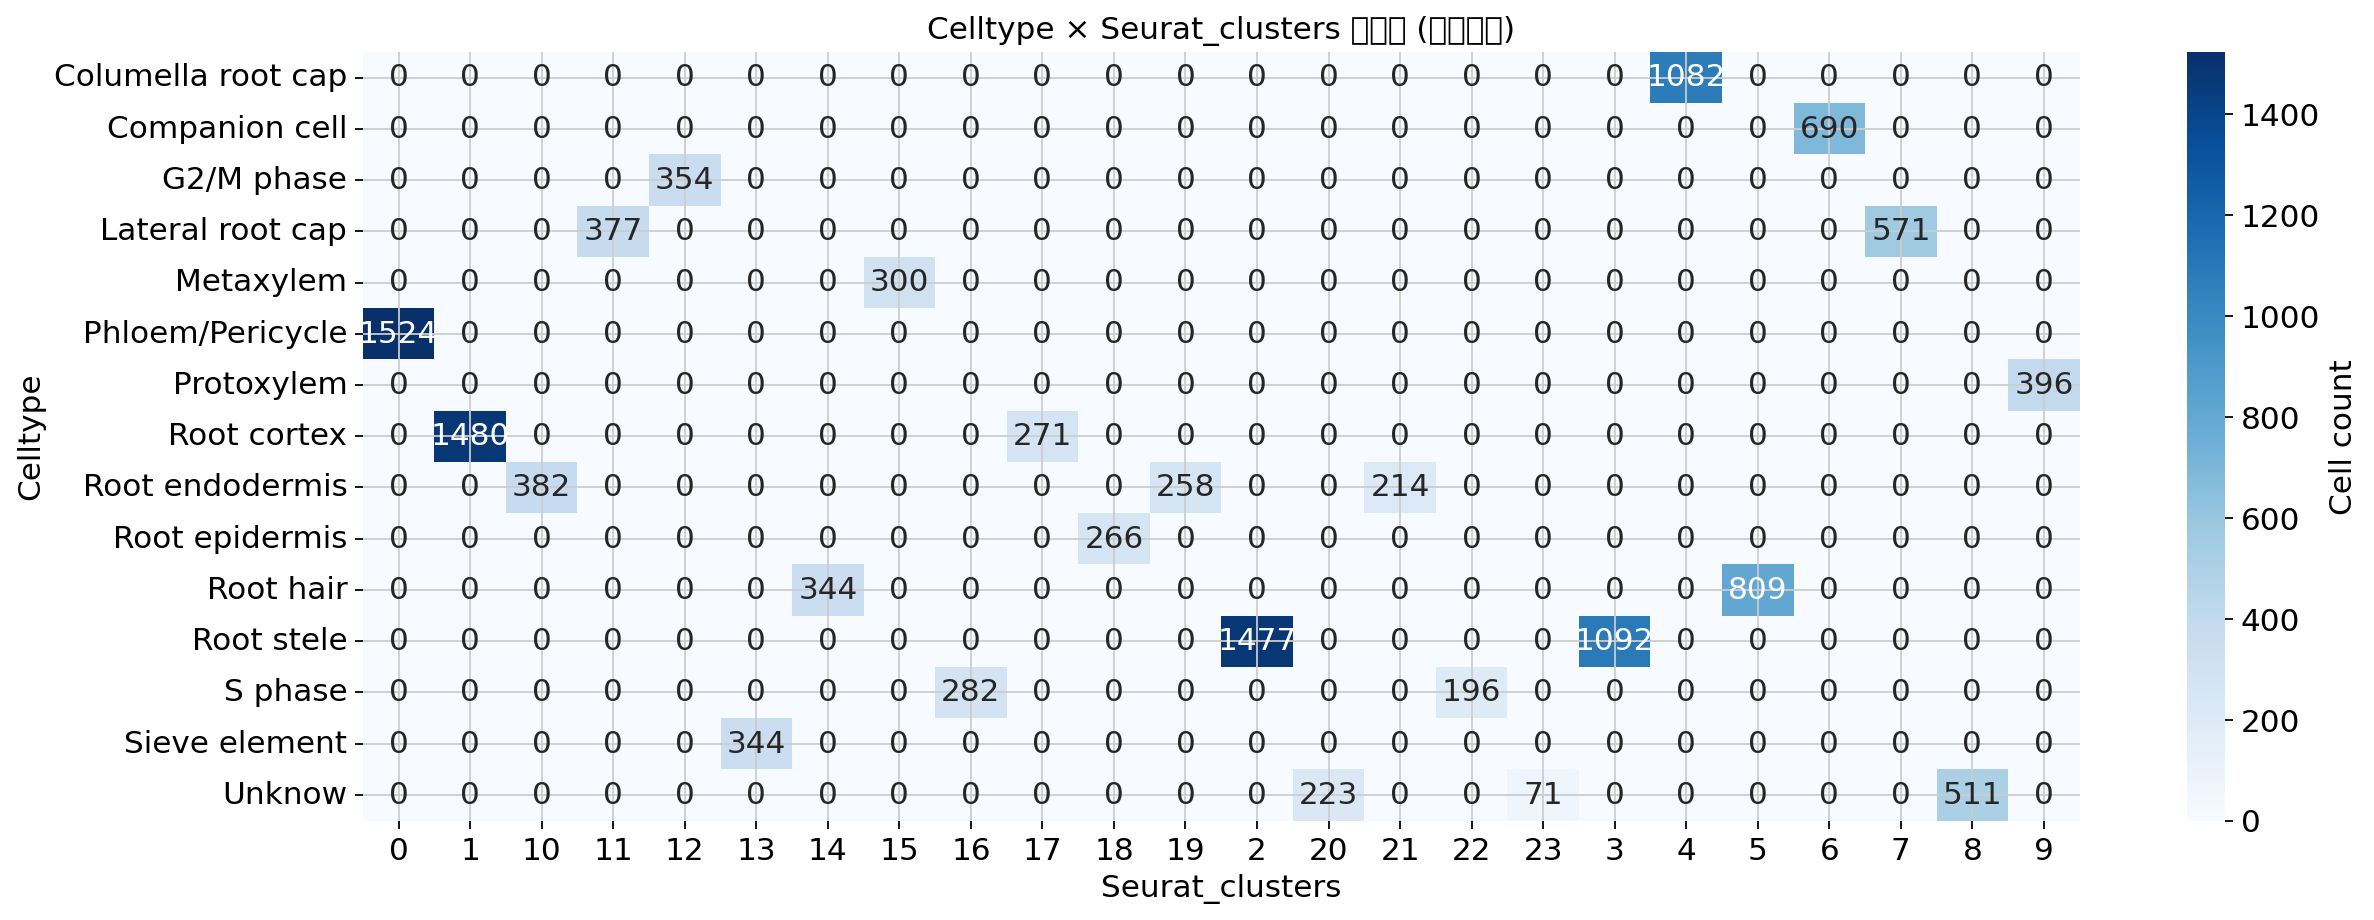

In [8]:
# 5.2 Seurat_clusters vs Celltype 对比
print("=" * 60)
print("🔀 Seurat_clusters (24) vs Celltype (15)")
print("=" * 60)

ct_cluster = pd.crosstab(adata.obs['Celltype'], adata.obs['Seurat_clusters'])
print(f"\n交叉表形状: {ct_cluster.shape} (Celltype × Seurat_clusters)")

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(ct_cluster, annot=True, fmt='d', cmap='Blues', ax=ax, cbar_kws={'label': 'Cell count'})
ax.set_xlabel('Seurat_clusters')
ax.set_ylabel('Celltype')
ax.set_title('Celltype × Seurat_clusters 交叉表 (部分展示)')
plt.tight_layout()
plt.savefig('../notebooks_figures/h5ad_anatomy_celltype_vs_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 6. var (基因元数据) 解析

**计算机视角**: 每一行是一个基因, 告诉你它叫什么、有什么属性。

In [9]:
print("=" * 60)
print("🧬 var 解析 (基因元数据)")
print("=" * 60)

print(f"\n  形状: {adata.var.shape}")
print(f"  列: {list(adata.var.columns)}")
print(f"\n  基因名示例 (前10个): {list(adata.var.index[:10])}")
print(f"  基因名示例 (后10个): {list(adata.var.index[-10:])}")

# 检查: 所有基因是否都是 AT 开头 (拟南芥基因命名)
at_prefix = adata.var.index.str.startswith('AT').sum()
print(f"\n  以 'AT' 开头: {at_prefix:,} / {adata.n_vars:,} ({at_prefix/adata.n_vars*100:.1f}%)")

# AT 命名规则: AT1GXXXXX = 1号染色体, G=gene
if at_prefix > 0:
    sample_genes = adata.var.index[:5]
    print(f"\n  拟南芥基因命名解读:")
    for g in sample_genes:
        parts = str(g).split('G')
        if len(parts) == 2:
            chr_num = parts[0].replace('AT', '').replace('AT', '')
            gene_num = parts[1]
            print(f"    {g} → 1号染色体, 基因编号 {gene_num}")
        else:
            print(f"    {g} → 命名格式: AT + 染色体号 + G + 基因号")

🧬 var 解析 (基因元数据)

  形状: (53678, 1)
  列: ['features']

  基因名示例 (前10个): ['AT1G01010', 'AT1G01020', 'AT1G01030', 'AT1G01040', 'AT1G01046', 'AT1G01050', 'AT1G01060', 'AT1G01070', 'AT1G01080', 'AT1G01090']
  基因名示例 (后10个): ['ATMG01170-1', 'ATMG01170', 'ATMG01190', 'ATMG01270', 'ATMG01275-1', 'ATMG01275-3', 'ATMG01275', 'ATMG01320-2', 'ATMG01320', 'ATMG01360']

  以 'AT' 开头: 32,248 / 53,678 (60.1%)

  拟南芥基因命名解读:
    AT1G01010 → 1号染色体, 基因编号 01010
    AT1G01020 → 1号染色体, 基因编号 01020
    AT1G01030 → 1号染色体, 基因编号 01030
    AT1G01040 → 1号染色体, 基因编号 01040
    AT1G01046 → 1号染色体, 基因编号 01046


---

## 7. raw 数据分析

**raw 是预处理前的备份** — 检查它的存在和内容, 是验证 "数据是否被篡改" 的关键。

In [10]:
print("=" * 60)
print("📦 raw 数据检查")
print("=" * 60)

print(f"\n  raw 是否存在: {adata.raw is not None}")
if adata.raw is not None:
    print(f"  raw.shape:      {adata.raw.shape}")
    print(f"  raw.n_vars:    {adata.raw.n_vars}")
    print(f"  raw.n_obs:     {adata.raw.n_obs}")
    print(f"  raw.X 是否等于当前 X: {'⚠️ 是' if adata.raw.X is adata.X else '✅ 不同 — raw 是独立的备份'}")
    
    # 对比 raw 和当前 X
    if sp.issparse(adata.raw.X) and sp.issparse(adata.X):
        raw_nnz = adata.raw.X.nnz
        cur_nnz = adata.X.nnz
        print(f"\n  raw.nnz:    {raw_nnz:,}")
        print(f"  current X.nnz: {cur_nnz:,}")
        if raw_nnz == cur_nnz:
            print(f"  结论: raw 和 X 基因数相同, 说明数据未被过滤 (未做 HVG 筛选)")
        else:
            print(f"  结论: raw 基因数 > 当前 X 基因数, 说明当前 X 经过了基因过滤")
    
    # 检查 raw X 是否为整数 (counts 的标志)
    if sp.issparse(adata.raw.X):
        raw_sample = adata.raw.X.data[:100_000]
        is_raw_int = np.allclose(raw_sample, raw_sample.astype(int), atol=1e-3)
        print(f"\n  raw.X 是否接近整数 (Counts 标志): {is_raw_int} {'✅ 是原始 Counts' if is_raw_int else '⚠️ 可能已处理'}")

📦 raw 数据检查

  raw 是否存在: True
  raw.shape:      (13514, 53678)
  raw.n_vars:    53678
  raw.n_obs:     13514
  raw.X 是否等于当前 X: ✅ 不同 — raw 是独立的备份

  raw.nnz:    17,378,932
  current X.nnz: 17,378,932
  结论: raw 和 X 基因数相同, 说明数据未被过滤 (未做 HVG 筛选)

  raw.X 是否接近整数 (Counts 标志): True ✅ 是原始 Counts


---

## 8. layers 检查

**layers 是存放多个版本表达矩阵的地方** — 比如 counts 版本、normalized 版本可以共存。

In [11]:
print("=" * 60)
print("📚 layers 检查")
print("=" * 60)

if adata.layers:
    print(f"\n  存在的 layers: {list(adata.layers.keys())}")
    for name, layer in adata.layers.items():
        if sp.issparse(layer):
            print(f"\n  layer '{name}':")
            print(f"    shape: {layer.shape}")
            print(f"    type:  sparse ({type(layer).__name__})")
            print(f"    nnz:   {layer.nnz:,}")
            sample = layer.data[:1000]
            print(f"    data 范围: [{sample.min():.4f}, {sample.max():.4f}]")
            print(f"    data 均值: {sample.mean():.4f}")
            is_int = np.allclose(sample, sample.astype(int), atol=1e-3)
            print(f"    是否整数:  {is_int}")
else:
    print("\n  ❌ layers 为空 — 没有存储额外矩阵版本")
    print("  这意味着:")
    print("    1. 原始 counts 只存在于 raw.X 或 X 中")
    print("    2. 没有预先计算好的 norm_log 或 counts layers")
    print("    3. preprocess.py 需要自己计算这些")

📚 layers 检查

  ❌ layers 为空 — 没有存储额外矩阵版本
  这意味着:
    1. 原始 counts 只存在于 raw.X 或 X 中
    2. 没有预先计算好的 norm_log 或 counts layers
    3. preprocess.py 需要自己计算这些


---

## 9. QC 指标可视化

对于计算机学生, 这一步是"数据清洗前的 assert" — 理解数据范围, 才能判断后续处理是否正确。

/tmp/ipykernel_1685519/1579484221.py:32: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/1579484221.py:32: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/1579484221.py:32: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/1579484221.py:32: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/1579484221.py:32: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/1579484221.py:32: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1685519/1579484221.py:32: UserWarning: Glyph 20301 (\N{CJK UN

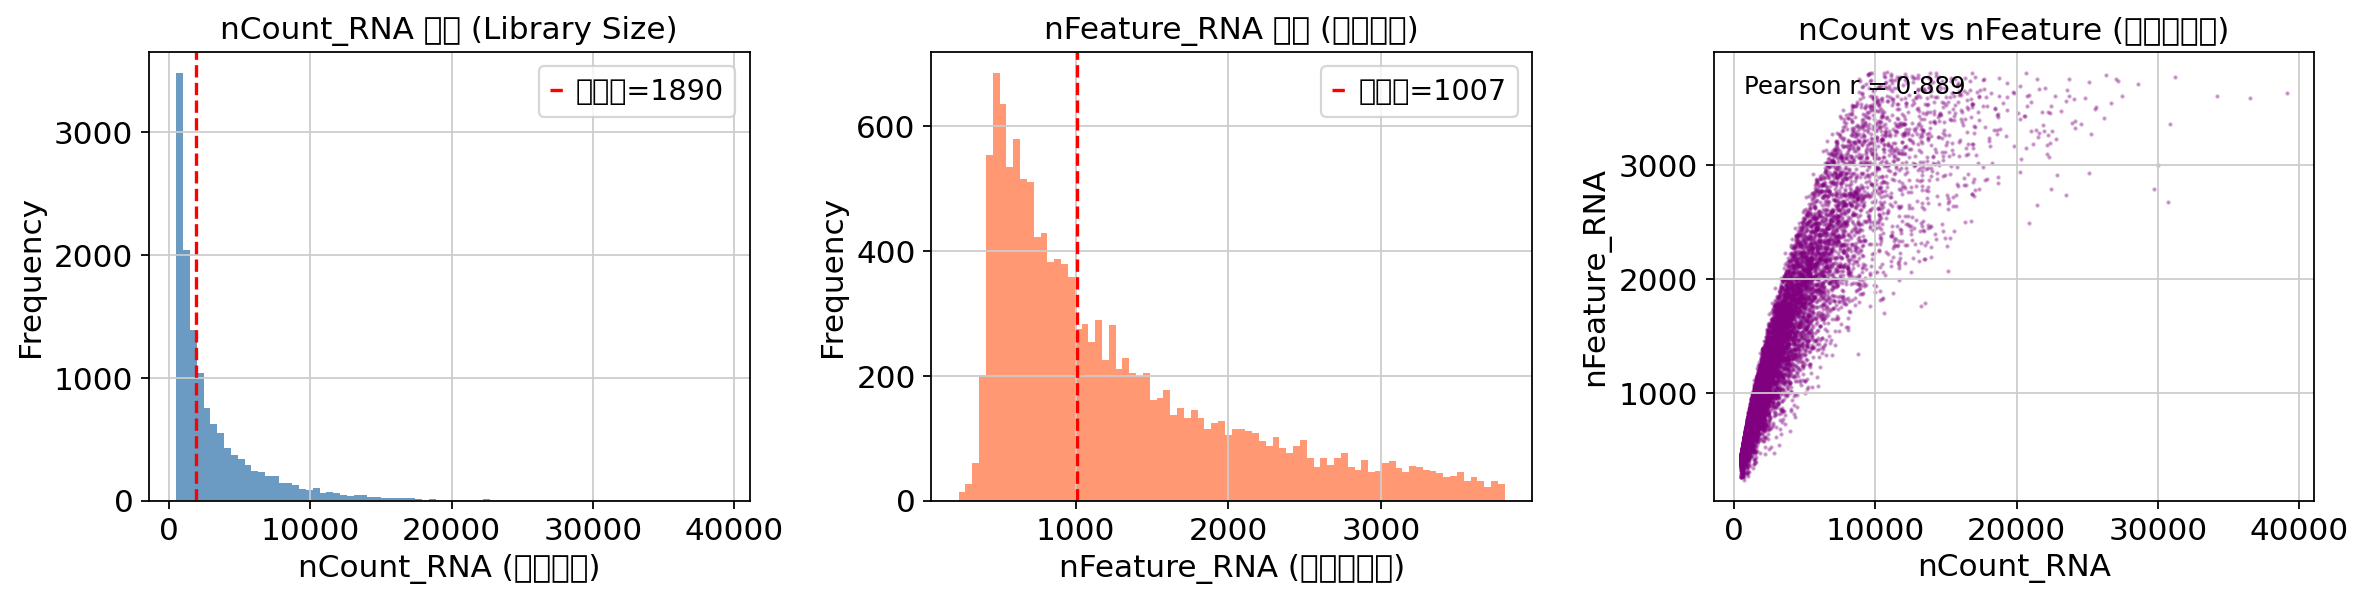


  📊 图表已保存
  nCount vs nFeature 相关系数: 0.889
  → 强正相关: 测序深度越高, 检测到的基因越多 (正常)


In [12]:
# 9.1 nCount_RNA 和 nFeature_RNA 分布
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# nCount_RNA 分布
axes[0].hist(adata.obs['nCount_RNA'], bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('nCount_RNA (总分子数)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('nCount_RNA 分布 (Library Size)')
axes[0].axvline(np.median(adata.obs['nCount_RNA']), color='red', linestyle='--', label=f'中位数={np.median(adata.obs["nCount_RNA"]):.0f}')
axes[0].legend()

# nFeature_RNA 分布
axes[1].hist(adata.obs['nFeature_RNA'], bins=80, color='coral', edgecolor='none', alpha=0.8)
axes[1].set_xlabel('nFeature_RNA (表达基因数)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('nFeature_RNA 分布 (检测深度)')
axes[1].axvline(np.median(adata.obs['nFeature_RNA']), color='red', linestyle='--', label=f'中位数={np.median(adata.obs["nFeature_RNA"]):.0f}')
axes[1].legend()

# nCount vs nFeature 散点图
axes[2].scatter(adata.obs['nCount_RNA'], adata.obs['nFeature_RNA'], 
                s=1, alpha=0.3, color='purple')
axes[2].set_xlabel('nCount_RNA')
axes[2].set_ylabel('nFeature_RNA')
axes[2].set_title('nCount vs nFeature (相关性检验)')

# 计算相关系数
corr = np.corrcoef(adata.obs['nCount_RNA'], adata.obs['nFeature_RNA'])[0, 1]
axes[2].text(0.05, 0.95, f'Pearson r = {corr:.3f}', transform=axes[2].transAxes,
             fontsize=11, verticalalignment='top')

plt.tight_layout()
plt.savefig('../notebooks_figures/h5ad_anatomy_qc_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  📊 图表已保存")
print(f"  nCount vs nFeature 相关系数: {corr:.3f}")
print(f"  → {'强正相关: 测序深度越高, 检测到的基因越多 (正常)' if corr > 0.7 else '弱相关: 可能存在异常细胞'}")

/tmp/ipykernel_1685519/1516676636.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=adata.obs, x='Celltype_cat', y='nCount_RNA', ax=axes[0], palette='tab20')
/tmp/ipykernel_1685519/1516676636.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_1685519/1516676636.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=adata.obs, x='Celltype_cat', y='nFeature_RNA', ax=axes[1], palette='tab20')
/tmp/ipykernel_1685519/1516676636.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks

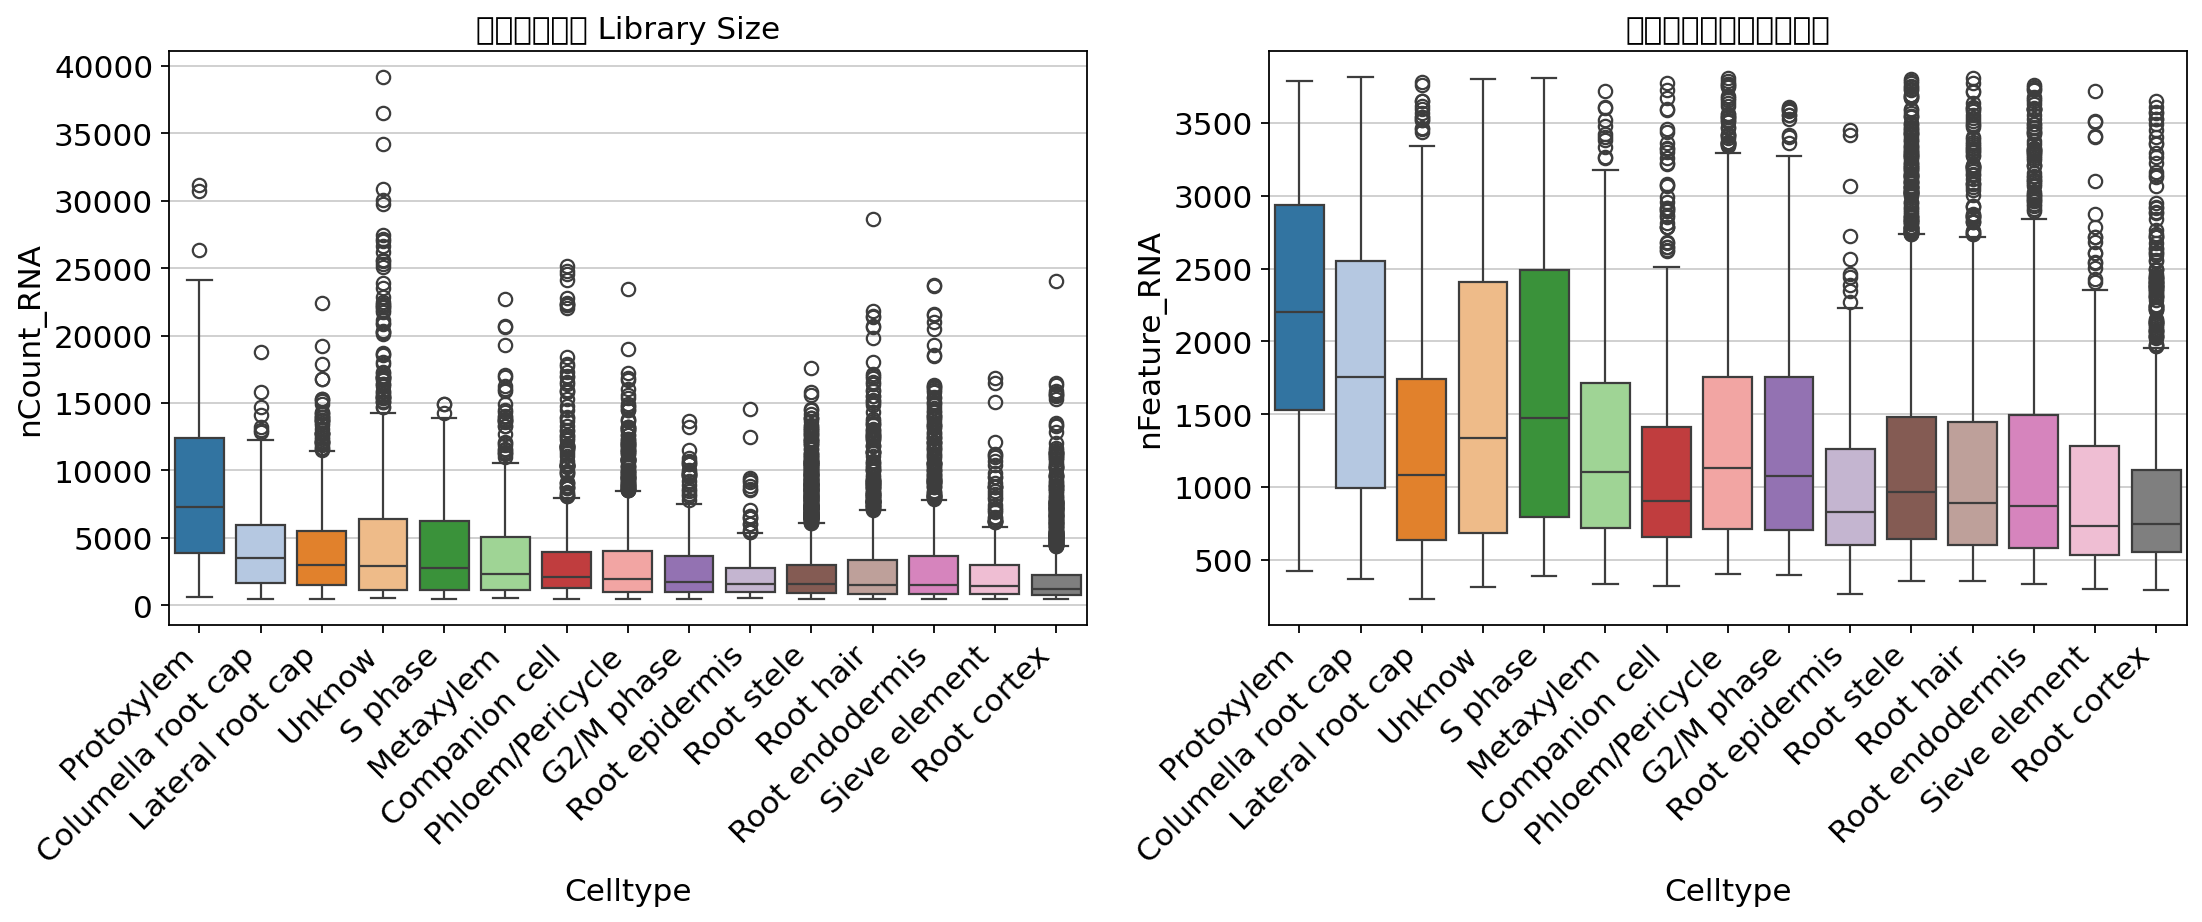

In [13]:
# 9.2 每个 Celltype 的 QC 指标
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 按 Celltype 分组的 nCount
celltype_order = adata.obs.groupby('Celltype')['nCount_RNA'].median().sort_values(ascending=False).index
adata.obs['Celltype_cat'] = pd.Categorical(adata.obs['Celltype'], categories=celltype_order, ordered=True)

sns.boxplot(data=adata.obs, x='Celltype_cat', y='nCount_RNA', ax=axes[0], palette='tab20')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_xlabel('Celltype')
axes[0].set_ylabel('nCount_RNA')
axes[0].set_title('各细胞类型的 Library Size')

# 按 Celltype 分组的 nFeature
sns.boxplot(data=adata.obs, x='Celltype_cat', y='nFeature_RNA', ax=axes[1], palette='tab20')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_xlabel('Celltype')
axes[1].set_ylabel('nFeature_RNA')
axes[1].set_title('各细胞类型的检测基因数')

plt.tight_layout()
plt.savefig('../notebooks_figures/h5ad_anatomy_qc_by_celltype.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 10. 关键发现总结

### 10.1 SRP182008 是一个怎样的 h5ad?

✅ **合理的完整 h5ad**, 具备 benchmark 所需的所有关键信息:

| 组件 | 状态 | 说明 |
|------|------|------|
| X (表达矩阵) | ✅ | 13,514 cells × 53,678 genes, 稀疏 CSR, float64 |
| obs (细胞注释) | ✅ | 包含 Celltype (GT 标签), nCount_RNA, nFeature_RNA, Seurat_clusters 等 |
| var (基因注释) | ⚠️ 简略 | 只有 `features` 列 (基因名), 无额外注释 |
| raw (原始备份) | ✅ | 完整备份, 基因数相同 |
| layers | ❌ 空 | 无预存 counts/norm_log — preprocess.py 必须自己计算 |
| obsm | ❌ 空 | 无 PCA/UMAP 嵌入 |

### 10.2 数据的生物学背景

- **物种**: 拟南芥 (Arabidopsis thaliana), 基因名格式 `AT1GXXXXX`
- **组织**: 根部 (Root)
- **细胞类型**: 15 种, 包括根皮层 (Root cortex)、根毛 (Root hair)、韧皮部 (Phloem) 等
- **数据来源**: 来自 NCBI SRA study SRP182008 (Single-cell RNA-seq of Arabidopsis root)
- **建库方法**: 不明 (Libraries 列有值但未解析)

### 10.3 预处理前的计算机断言 (assert)

基于以上分析, 正式预处理前应验证:

```python
assert adata.X.dtype == np.float64           # 当前是 float64 ✓
assert np.allclose(X_data, X_data.astype(int), atol=1e-3)  # 是 Counts ✓
assert adata.n_obs == 13514                 # 13514 cells ✓
assert adata.n_vars == 53678                # 53678 genes ✓
assert 'Celltype' in adata.obs.columns      # 有 GT 标签 ✓
assert adata.raw is not None                # 有原始备份 ✓
assert adata.layers == {}                   # 无预存 layers ✓
assert np.median(adata.obs['nCount_RNA']) == 1889.5  # 中位数 ~1890 ✓
```

### 10.4 预处理的风险点

| 风险 | 说明 |
|------|------|
| **无需 log1p 检查** | X 是 float64 而非 int64, 说明可能已部分处理过。需要先确认 X 是否为原始整数 counts |
| **Percent.mt 列** | 拟南芥线粒体基因不以 `MT-` 开头, 此列数值可能不准确 |
| **HVG 筛选** | 当前无预存 layers, HVG 筛选后原始数据可通过 raw 恢复 |
| **Unknown 细胞** | 聚类评估时需考虑是否过滤 `"Unknow"` 类型 |